# Cone-linearized annulus-disc analysis
**The experiment.** Every natural-image annulus patch is shown three ways, interleaved:

| `stimulusTag` | what it is |
|---|---|
| `image` | the image patch itself |
| `intensity` | uniform annulus at the linear-equivalent intensity (patch averaged over the surround RF) |
| `linConeIntensity` / `lin cone intensity` | uniform annulus at the **cone-linearized** equivalent intensity — averaged after a Weber cone nonlinearity `I / (I + WeberConstant)` |

Comparing image against each annulus asks how much of the cell's preference for the real image
survives when the averaging happens in cone-response space instead of intensity space. The
measure is the nonlinearity index per patch, exactly as `computeNLI` defines it:

$$\mathrm{NLI} = \frac{\mathrm{image} - \mathrm{disc}}{|\mathrm{image}| + |\mathrm{disc}|}$$

set to zero when neither response clears a recording-mode threshold.


In [1]:
import contextlib
import io

import retinanalysis as ra
import numpy as np
import pandas as pd

from retinanalysis.SCutils import explore as sc
from retinanalysis.SCutils.protocols import linear_equivalent_disc as led

## 1. Find experiment dates and cells

This notebook analyzes `LinearEquivalentAnnulus`. The fast compact table has one row per
experiment and cell. `date_index` numbers each experiment date so it can be selected directly
in Section 1a. Detailed block, amplifier, recording-mode, and FilterWheel metadata are deferred
until one date is selected, which keeps a kernel restart quick.


In [2]:
PROC = 'LinearEquivalentAnnulus'

protocol_cells = led.find_protocol_cells(PROC, show=False)
protocol_cells.insert(
    0, 'date_index', pd.factorize(protocol_cells['exp_name'], sort=False)[0] + 1)
print(f'{PROC}: {len(protocol_cells)} cells across '
      f'{protocol_cells.exp_name.nunique()} experiments')
sc.scroll_table(protocol_cells, height=420)


LinearEquivalentAnnulus: 91 cells across 39 experiments


date_index,exp_name,cell_label,protocol
1,2022-07-05_G,Cell2,LinearEquivalentAnnulus
1,2022-07-05_G,Cell4,LinearEquivalentAnnulus
1,2022-07-05_G,Cell5,LinearEquivalentAnnulus
1,2022-07-05_G,Cell6,LinearEquivalentAnnulus
1,2022-07-05_G,Cell7,LinearEquivalentAnnulus
1,2022-07-05_G,Cell8,LinearEquivalentAnnulus
1,2022-07-05_G,Cell9,LinearEquivalentAnnulus
2,2022-07-12_G,Cell1,LinearEquivalentAnnulus
2,2022-07-12_G,Cell2,LinearEquivalentAnnulus
2,2022-07-12_G,Cell3,LinearEquivalentAnnulus


'\n<style>\n.ra-tbl { overflow: auto; }\n.ra-tbl table { border-collapse: collapse; font-size: 12.5px;\n                font-variant-numeric: tabular-nums; }\n.ra-tbl th { position: sticky; top: 0; z-index: 1; text-align: left;\n             font-weight: 600; padding: 4px 12px 4px 0;\n             border-bottom: 1px solid rgba(128,128,128,0.6);\n             background: var(--jp-layout-color0, #fff); }\n.ra-tbl td { padding: 2px 12px 2px 0; vertical-align: top;\n             white-space: nowrap; }\n.ra-tbl tr.grp > td { border-top: 1px solid rgba(128,128,128,0.28); }\n.ra-tbl td.num { text-align: right; }\n.ra-tbl td.lead { font-weight: 600; }\n.ra-tbl summary { cursor: pointer; margin: 2px 0; }\n</style>\n<div class="ra-tbl" style="max-height:420px"><table><thead><tr><th>date_index</th><th>exp_name</th><th>cell_label</th><th>protocol</th></tr></thead><tbody><tr><td>1</td><td>2022-07-05_G</td><td>Cell2</td><td>LinearEquivalentAnnulus</td></tr><tr><td>1</td><td>2022-07-05_G</td><td>Cell

### 1a. Choose a date and group its recordings

Choose one `date_index` from the Section 1 table. Only that date is grouped below, so the
overview is not repeated for every experiment. Each row is one cell × resolved recording
mode × disc site × light setting, with blocks from the same condition pooled. The tree table
keeps only: `exp_name`, `cell_label`, `cell_type_short`,
resolved `onlineAnalysis`, `site`, `light_settings`, `block_ids`, `image_names`, short
`protocols`, and protocol-setting `maxIntensity`. A blank `maxIntensity` means the older
protocol did not record that setting.

In [16]:
# Choose a date_index shown in Section 1.
DATE_INDEX = 39

date_rows = protocol_cells.loc[protocol_cells.date_index.eq(DATE_INDEX)]
if date_rows.empty:
    raise ValueError(f'date_index {DATE_INDEX} is not available for {PROC}')
EXP_NAME = date_rows.exp_name.iloc[0]

# Only now load detailed blocks and resolve recording mode from the amplifier.
df_blocks = led.find_blocks(
    exp_names=[EXP_NAME], protocols=[PROC], show=False)
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    df_blocks = led.check_series_resistance(
        df_blocks, show=False, sample_series_resistance=True)
selected_blocks = df_blocks.copy()
if selected_blocks.empty:
    raise ValueError(f'{EXP_NAME!r} is not available for {PROC}')
groups = led.group_blocks(selected_blocks)

28 recording groups (experiment x cell x mode x site x light level)


exp_name,cell_label,cell_type_short,onlineAnalysis,site,light_settings,block_ids,image_names,protocols,maxIntensity
2026-08-18_G_2,Cell5,ON-parasol,extracellular,surround,FW0/bg0.115072,37711,['02999'],LinearEquivalentAnnulus,77000.0
,,,extracellular,surround,FW0/bg0.139055,37710,['02733'],LinearEquivalentAnnulus,77000.0
,,,extracellular,surround,FW0/bg0.155824,37708,['01769'],LinearEquivalentAnnulus,77000.0
,,,extracellular,surround,FW0/bg0.156863,37709,['01829'],LinearEquivalentAnnulus,77000.0
,,,extracellular,surround,FW0/bg0.199407,37707,['00152'],LinearEquivalentAnnulus,77000.0
,,,extracellular,surround,FW1/bg0.115072,37718,['02999'],LinearEquivalentAnnulus,7600.0
,,,extracellular,surround,FW1/bg0.139055,37717,['02733'],LinearEquivalentAnnulus,7600.0
,,,extracellular,surround,FW1/bg0.14899,37714,['01192'],LinearEquivalentAnnulus,7600.0
,,,extracellular,surround,FW1/bg0.155824,37715,['01769'],LinearEquivalentAnnulus,7600.0
,,,extracellular,surround,FW1/bg0.156863,37716,['01829'],LinearEquivalentAnnulus,7600.0


## 2. What the cell was shown

Continue from the date selected in Section 1a. The dropdown contains every recorded `imageName`
for that date; choosing one redraws an example patch and its two equivalent discs. The three
stimuli use a common grey scale: the natural-image patch as seen through
the aperture, the uniform disc at the linear-equivalent intensity, and the uniform disc at the
cone-linearized intensity. The image is loaded from the van Hateren resources in the turner
package the same way `NaturalImageFlashProtocol.m` does — big-endian `.iml`, rescaled so the
brightest pixel is 1, at 6.6 µm per image pixel.

A useful check that the geometry is right: the mean intensity inside the aperture should land on
the recorded `equivalentIntensity`, since that is what the equivalent disc is defined to be.

In [4]:
image_example = led.stimulus_example_widget(selected_blocks)
image_example

## 3. Analyze one cell condition

Enter the cell label, resolved `onlineAnalysis`, and numeric FilterWheel value. The first output
lists the matching block IDs and one row per `imageName`, including its epoch count and
`meanIntensity = maxIntensity × backgroundIntensity`.

Responses use the exact onset window from `preTime` through `preTime + stimTime`: spike count
for extracellular recordings and baseline-subtracted signed area (pA·s) for whole-cell
recordings. Each scatter point is one `(imageName, patchIndex)` pair; x and y error bars are
SEM across repeat epochs. The per-image and pooled figures show image vs standard disc in grey
and image vs cone-linearized disc in red, with a unity line. Patch indices that restart in a new
image remain separate. The final figure uses empirical NLI CDFs and a second panel with
the mean ± SEM across every image-specific patch for this cell. After Section 3a has saved this
exact block set once, rerunning after a kernel restart reloads those patch results instead of
re-reading traces and detecting spikes. Pass `reuse_saved=False` to `analyze_condition` when a
deliberate raw-data recomputation is needed.

2026-08-18_G_2/Cell7 | extracellular | FilterWheel 1
block_ids: 37732, 37733
2 imageNames | 83 epochs


imageName,block_ids,epochs,maxIntensity,backgroundIntensity,meanIntensity
00152,[37732],40,7600.0,0.19940717249552456,1515.4945109659866
02999,[37733],43,7600.0,0.11507195997437214,874.5468958052282


analyzed 2 blocks, 83 epochs, 20 image/patch pairs


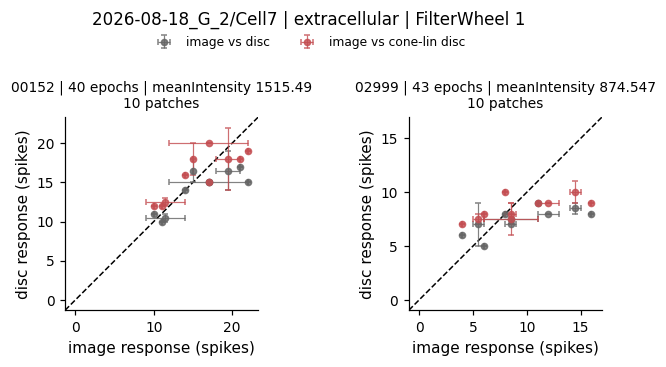

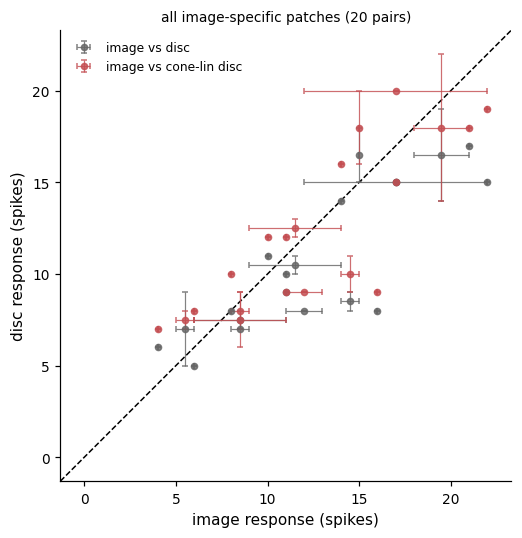

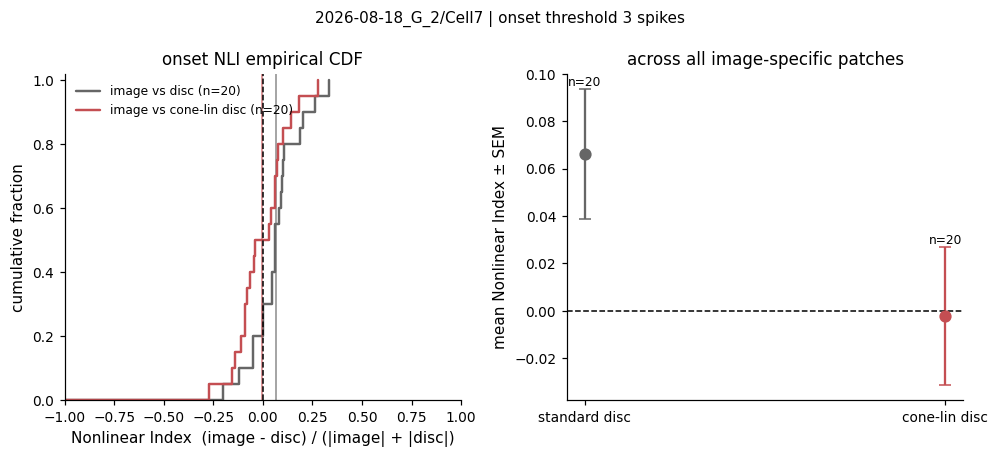

In [28]:
# Define one condition within the experiment selected in Section 1a.
CELL_LABEL = 'Cell7'
ONLINE_ANALYSIS = 'extracellular'  # 'extracellular', 'exc', or 'inh'
FILTER_WHEEL_VALUE = 1.0          # authoritative numeric FilterWheel value

condition_blocks = led.select_condition_blocks(
    selected_blocks, CELL_LABEL, ONLINE_ANALYSIS, FILTER_WHEEL_VALUE)
condition = led.analyze_condition(condition_blocks)
image_fig, pooled_fig, nli_fig = led.plot_condition(condition)

### 3a. Save this cell for population analysis

Save one compressed HDF5 record for the selected cell condition, similar to a MATLAB struct
containing arrays. Cell metadata is stored once, and the image summary and patch responses are
kept as typed arrays instead of tens of thousands of CSV rows. `condition_population_table()`
still expands the selected condition for display when needed. Each distinct date/cell/mode/FW
condition gets its own file; rerunning that exact condition replaces its file rather than
duplicating it. The file also becomes the fast restart source for Section 3 when the selected
block IDs match. Later,
`led.load_condition_outputs()` combines every saved cell into one population table.

In [27]:
condition_output_path = led.save_condition_output(condition)
population_ready = led.condition_population_table(condition)
sc.scroll_table(
    population_ready, height=360,
    num_cols=('filter_wheel_ndf', 'patchIndex', 'maxIntensity',
              'meanIntensity', 'image_response', 'disc_response',
              'cone_disc_response', 'nli_image_vs_disc',
              'nli_image_vs_cone_disc'));

saved 1 condition (30 patches as arrays) to /Volumes/ChrisNewSSD/retinanalysis_output/linear_equivalent_disc/condition_outputs/2026-08-18_G_2__Cell7__extracellular__surround__LinearEquivalentAnnulus__FW0.h5


date,cell_label,cell_type,onlineAnalysis,protocol,site,filter_wheel_ndf,imageName,patchIndex,patch_key,block_ids,image_epochs,maxIntensity,backgroundIntensity,meanIntensity,response_units,image_response,image_response_sem,image_trials,disc_response,disc_response_sem,disc_trials,cone_disc_response,cone_disc_response_sem,cone_disc_trials,nli_image_vs_disc,nli_image_vs_cone_disc,output_version
2026-08-18_G_2,Cell7,ON-parasol,extracellular,LinearEquivalentAnnulus,surround,0.0,00152,1.0,00152:1,37729,40,77000.0,0.19940717249552456,15354.35228215539,spikes,21.5,0.5,2,20.0,1.0,2,22.0,2.0,2,0.03614457831325301,-0.011494252873563218,1
2026-08-18_G_2,Cell7,ON-parasol,extracellular,LinearEquivalentAnnulus,surround,0.0,00152,2.0,00152:2,37729,40,77000.0,0.19940717249552456,15354.35228215539,spikes,14.0,1.0,2,12.5,0.5,2,23.0,0.0,2,0.05660377358490566,-0.24324324324324326,1
2026-08-18_G_2,Cell7,ON-parasol,extracellular,LinearEquivalentAnnulus,surround,0.0,00152,3.0,00152:3,37729,40,77000.0,0.19940717249552456,15354.35228215539,spikes,18.5,7.5,2,22.5,0.5,2,25.5,1.4999999999999998,2,-0.0975609756097561,-0.1590909090909091,1
2026-08-18_G_2,Cell7,ON-parasol,extracellular,LinearEquivalentAnnulus,surround,0.0,00152,4.0,00152:4,37729,40,77000.0,0.19940717249552456,15354.35228215539,spikes,24.5,0.5,2,20.0,0.0,1,26.0,0.0,1,0.10112359550561797,-0.0297029702970297,1
2026-08-18_G_2,Cell7,ON-parasol,extracellular,LinearEquivalentAnnulus,surround,0.0,00152,5.0,00152:5,37729,40,77000.0,0.19940717249552456,15354.35228215539,spikes,17.0,0.0,1,17.0,0.0,1,22.0,0.0,1,0.0,-0.1282051282051282,1
2026-08-18_G_2,Cell7,ON-parasol,extracellular,LinearEquivalentAnnulus,surround,0.0,00152,6.0,00152:6,37729,40,77000.0,0.19940717249552456,15354.35228215539,spikes,23.0,0.0,1,16.0,0.0,1,24.0,0.0,1,0.1794871794871795,-0.02127659574468085,1
2026-08-18_G_2,Cell7,ON-parasol,extracellular,LinearEquivalentAnnulus,surround,0.0,00152,7.0,00152:7,37729,40,77000.0,0.19940717249552456,15354.35228215539,spikes,25.0,0.0,1,23.0,0.0,1,26.0,0.0,1,0.041666666666666664,-0.0196078431372549,1
2026-08-18_G_2,Cell7,ON-parasol,extracellular,LinearEquivalentAnnulus,surround,0.0,00152,8.0,00152:8,37729,40,77000.0,0.19940717249552456,15354.35228215539,spikes,17.0,0.0,1,15.0,0.0,1,22.0,0.0,1,0.0625,-0.1282051282051282,1
2026-08-18_G_2,Cell7,ON-parasol,extracellular,LinearEquivalentAnnulus,surround,0.0,00152,9.0,00152:9,37729,40,77000.0,0.19940717249552456,15354.35228215539,spikes,12.0,0.0,1,12.0,0.0,1,17.0,0.0,1,0.0,-0.1724137931034483,1
2026-08-18_G_2,Cell7,ON-parasol,extracellular,LinearEquivalentAnnulus,surround,0.0,00152,10.0,00152:10,37729,40,77000.0,0.19940717249552456,15354.35228215539,spikes,25.0,0.0,1,24.0,0.0,1,25.0,0.0,1,0.02040816326530612,0.0,1


### 3b. Check saved cells

Read only the small metadata attributes from saved annulus conditions—without loading the
patch arrays—and list date, cell label/type, resolved `onlineAnalysis`, and FilterWheel value.

In [29]:
saved_cells = led.load_condition_index(protocol=PROC)
print(f'{len(saved_cells)} saved cell condition(s)')
sc.scroll_table(saved_cells, height=300, num_cols=('filter_wheel_ndf',));

38 saved cell condition(s)


date,cell_label,cell_type,onlineAnalysis,filter_wheel_ndf
2026-03-09_E,Cell1,OFF-parasol,extracellular,0.0
2026-03-09_E,Cell2,ON-parasol,extracellular,0.0
2026-03-10_E,Cell3,ON-parasol,extracellular,0.0
2026-03-17_E,Cell2,OFF-parasol,extracellular,0.0
2026-03-18_E,Cell1,ON-parasol,extracellular,0.0
2026-04-03_E,Cell4,OFF-parasol,extracellular,0.0
2026-04-03_E_2,Cell7,ON-parasol,extracellular,0.0
2026-04-04_E,Cell2,ON-parasol,extracellular,0.0
2026-04-14_E,Cell1,OFF-parasol,extracellular,0.0
2026-04-14_E,Cell2,ON-parasol,extracellular,0.0


## 5. Population by image and cell type

Load the saved `LinearEquivalentAnnulus` condition `.h5` files directly. First make one row
for each cell × FilterWheel × `imageName`: `meanIntensity` is the x value, and the two y values
are the mean patch NLI for the ordinary disc–image pair and cone-linearized disc–image pair.
Nothing is averaged across cells at this stage. Then group those rows into `[500, 1500)`,
`[1500, 3500)`, `[3500, 6000)`, and `[6000, 20000]` intensity ranges within each cell type.
Each plotted x value is the observed mean intensity in that group; y is population mean NLI
with SEM across the contributing cell/image rows. Grey is the ordinary disc and red is the
cone-linearized disc. Rows outside 500–20,000 remain in `image_nli` but are not grouped.


140 cell/image rows from 31 cells


exp_name,cell_label,cell_type,onlineAnalysis,filter_wheel_ndf,imageName,meanIntensity,n_patches,mean_nli_disc,mean_nli_cone_disc
2026-06-29_E,Cell2,OFF-midget,extracellular,0.0,02733,4171.656638511621,30,-0.32502310106771304,-0.13773162593175106
2026-06-29_E,Cell2,OFF-midget,extracellular,0.0,03758,4419.002332474051,30,-0.2391067490082517,-0.12638689803146005
2026-06-29_E,Cell2,OFF-midget,extracellular,0.0,01151,5467.900019009631,30,-0.24750964725260352,-0.1981644382565359
2026-06-29_E,Cell2,OFF-midget,extracellular,0.0,00152,5982.215174864138,30,-0.24769375698151447,0.0036612104646690955
2026-06-29_E,Cell4,OFF-midget,extracellular,0.0,03760,5276.202520645244,30,-0.37809409151179785,-0.16478341885209133
2026-06-30_E,Cell4,OFF-midget,extracellular,0.0,02999,3452.158799231536,27,-0.2793136081664181,-0.11172902195659105
2026-03-09_E,Cell1,OFF-parasol,extracellular,0.0,03760,4396.835433871036,20,-0.4414718896074866,-0.412461316585364
2026-03-09_E,Cell1,OFF-parasol,extracellular,0.0,01151,4556.583349174693,20,-0.34249568290347293,-0.35593507884319786
2026-03-17_E,Cell2,OFF-parasol,extracellular,0.0,03760,4396.835433871036,30,-0.38816736089096,-0.1979660501638806
2026-03-17_E,Cell2,OFF-parasol,extracellular,0.0,01151,4556.583349174693,30,-0.11904387181609458,-0.023833090254066734


140 of 140 rows are within 500–20000


cell_type,light_level,light_min,light_max,meanIntensity,n_cells,n_cell_images,mean_nli_disc,sem_nli_disc,mean_nli_cone_disc,sem_nli_cone_disc
OFF-midget,1500-3500,1500.0,3500.0,3452.158799231536,1,1,-0.2793136081664181,,-0.11172902195659105,
OFF-midget,3500-6000,3500.0,6000.0,5063.395337100937,2,5,-0.2874854691643761,0.027514490284682874,-0.12468103412143386,0.034389658044277294
OFF-parasol,3500-6000,3500.0,6000.0,4842.959973616355,6,12,-0.2628629115996377,0.029624018960655737,-0.10166699821557695,0.05261940355368121
OFF-parasol,6000-20000,6000.0,20000.0,11956.233233276682,2,5,-0.13663924854119974,0.026152130850731408,-0.010159732041848621,0.012169873041194903
ON-midget,3500-6000,3500.0,6000.0,4833.690377660137,2,4,0.29177436116249666,0.03174402620649468,0.07820624651549388,0.03341937380727648
ON-midget,6000-20000,6000.0,20000.0,11566.062806427646,1,4,0.22876100432288626,0.0696654895856576,-0.11558391566477924,0.01984239068749094
ON-parasol,500-1500,500.0,1500.0,1095.8720594031752,6,34,0.2554569850750201,0.029981580987996664,0.21961686071456377,0.040510750366910986
ON-parasol,1500-3500,1500.0,3500.0,2115.0508994240236,8,12,0.27344720135251843,0.04272151995149062,0.19081556999588425,0.059421544471177264
ON-parasol,3500-6000,3500.0,6000.0,4981.87170992729,10,18,0.2929701795738077,0.03962506126037805,-0.003577115150527283,0.0377308027197737
ON-parasol,6000-20000,6000.0,20000.0,12358.212068600811,8,45,0.19311484345141897,0.015162836181970708,-0.008987180799562103,0.008207688153967703


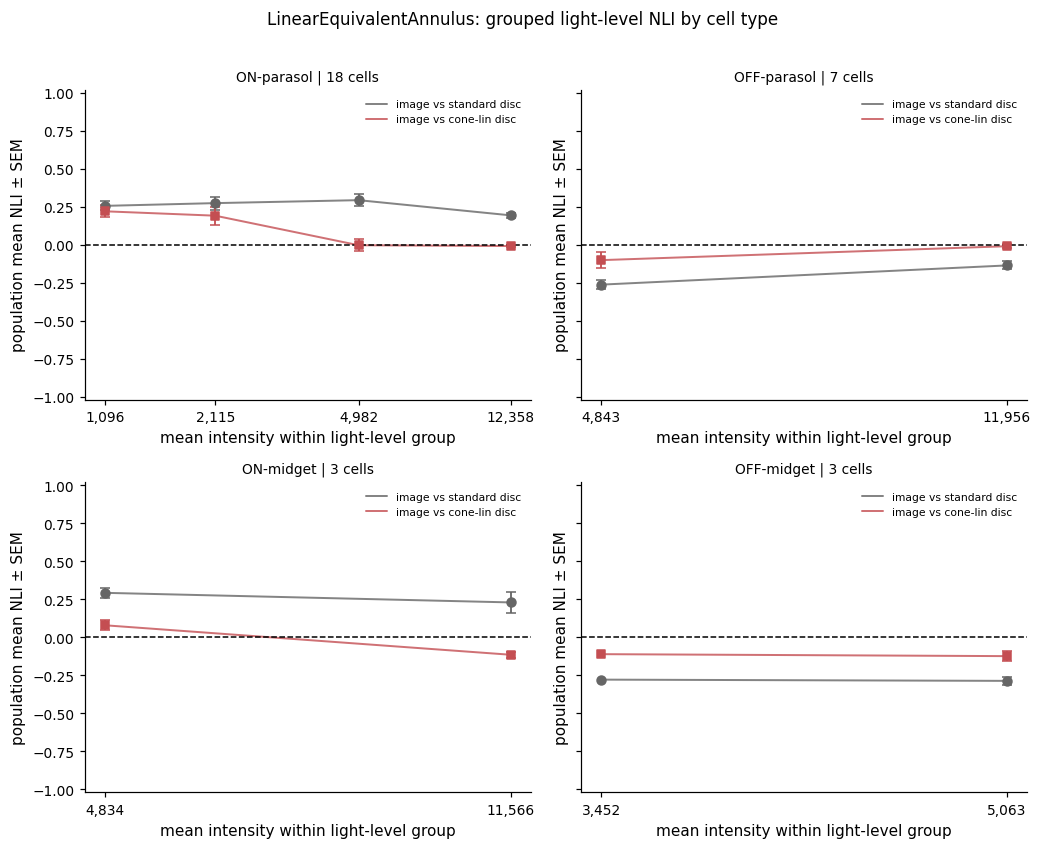

In [30]:
image_nli = led.load_condition_image_nli_summary(
    protocol='LinearEquivalentAnnulus')
print(f'{len(image_nli)} cell/image rows from {image_nli.cell_id.nunique()} cells')
image_nli_view = image_nli[[
    'exp_name', 'cell_label', 'cell_type', 'onlineAnalysis',
    'filter_wheel_ndf', 'imageName', 'meanIntensity', 'n_patches',
    'mean_nli_disc', 'mean_nli_cone_disc']]
sc.scroll_table(
    image_nli_view, height=360,
    num_cols=('filter_wheel_ndf', 'meanIntensity', 'n_patches',
              'mean_nli_disc', 'mean_nli_cone_disc'))
light_level_nli = led.summarize_image_nli_light_levels(image_nli)
print(f'{light_level_nli.n_cell_images.sum()} of {len(image_nli)} rows are within 500–20000')
sc.scroll_table(
    light_level_nli, height=300,
    num_cols=('light_min', 'light_max', 'meanIntensity', 'n_cells',
              'n_cell_images', 'mean_nli_disc', 'sem_nli_disc',
              'mean_nli_cone_disc', 'sem_nli_cone_disc'))
led.plot_image_nli_by_cell_type(image_nli);

### Pooled patch NLI distributions

Pool every patch NLI from the saved `LinearEquivalentAnnulus` `.h5` files, without averaging
by image or cell. The left panel is a normalized 50-bin density and the right panel is the
empirical CDF, each comparing ordinary and cone-linearized discs.


2223 standard and 2223 cone-lin patch NLIs from 2246 saved rows and 31 cells


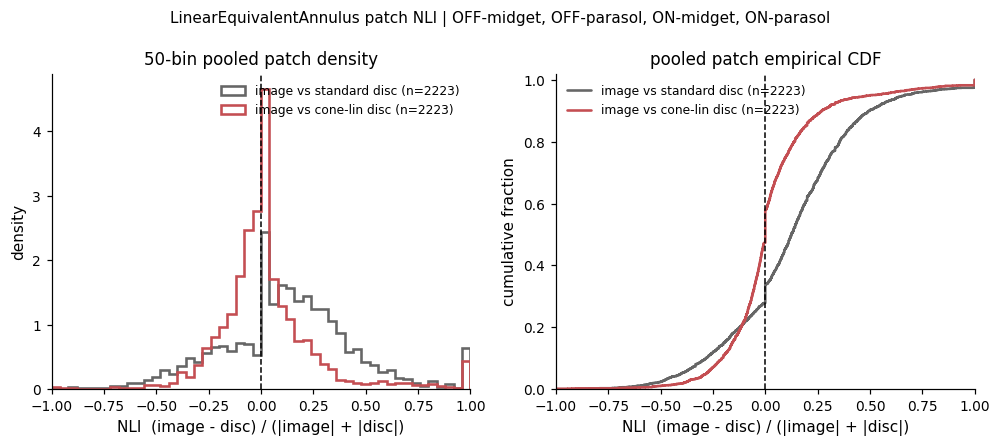

In [31]:
patch_nli = led.load_condition_patch_nli(
    protocol='LinearEquivalentAnnulus')
finite_patch_nli = np.isfinite(
    patch_nli[['nli_disc', 'nli_cone_disc']]).sum()
print(f"{finite_patch_nli['nli_disc']} standard and "
      f"{finite_patch_nli['nli_cone_disc']} cone-lin patch NLIs from "
      f'{len(patch_nli)} saved rows and {patch_nli.cell_id.nunique()} cells')
led.plot_pooled_patch_nli_distributions(patch_nli, bins=50);

### Cell-level averages at ~1k and ~10k

For each cell, pool all patches across all `imageName`s within `[500, 1500)` (~1k) or
`[6000, 20000]` (~10k), then calculate one ordinary-disc and one cone-linearized mean NLI.
Faint points are those cell means; large points and error bars are population mean ± SEM
across cells, so a cell with more patches does not get extra population weight.


cell_type,cell_id,exp_name,cell_label,light_level,light_min,light_max,meanIntensity,n_images,n_patches,mean_nli_disc,mean_nli_cone_disc
OFF-parasol,2026-04-24_E/Cell4,2026-04-24_E,Cell4,~10k,6000.0,20000.0,8044.318206118542,1,30,-0.042114999566419016,0.02315933461387802
ON-parasol,2026-05-08_G/Cell2,2026-05-08_G,Cell2,~1k,500.0,1500.0,1049.4478423836622,4,73,0.3343863432157502,0.38754406205269815
ON-parasol,2026-08-12_G/Cell1,2026-08-12_G,Cell1,~1k,500.0,1500.0,1111.787170489064,8,80,0.46651422527335384,0.4893639244493997
ON-parasol,2026-08-12_G_2/Cell4,2026-08-12_G_2,Cell4,~1k,500.0,1500.0,1128.0329932323639,7,70,0.2181217728169829,0.12383612930876069
ON-parasol,2026-08-12_G/Cell1,2026-08-12_G,Cell1,~10k,6000.0,20000.0,12906.641937333197,12,120,0.24651875073921853,-3.0452442259994393e-05
ON-parasol,2026-08-12_G/Cell3,2026-08-12_G,Cell3,~10k,6000.0,20000.0,12319.38663141174,6,60,0.28728675911809154,0.050626193180236166
ON-parasol,2026-08-12_G_2/Cell4,2026-08-12_G_2,Cell4,~10k,6000.0,20000.0,12092.626789499825,7,70,0.22475608333049285,-0.00045017275519135974


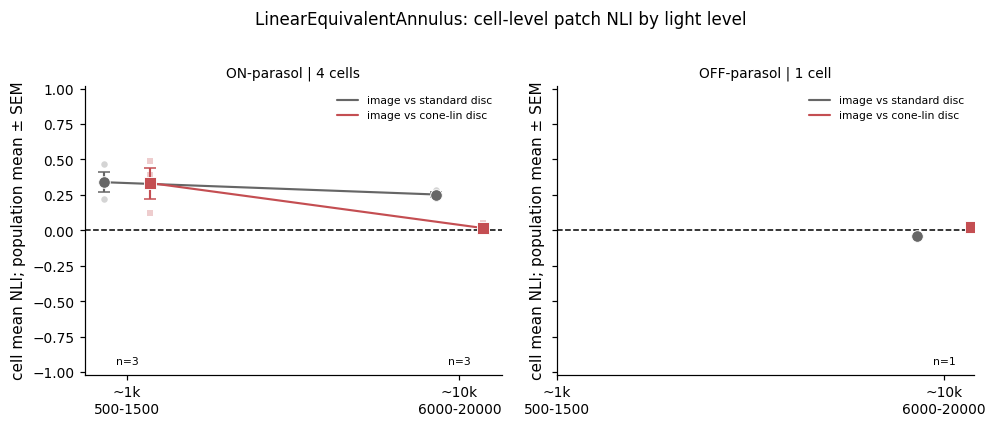

In [3]:
cell_light_nli = led.summarize_cell_patch_nli_light_levels(patch_nli)
sc.scroll_table(
    cell_light_nli, height=320,
    num_cols=('light_min', 'light_max', 'meanIntensity', 'n_images',
              'n_patches', 'mean_nli_disc', 'mean_nli_cone_disc'))
led.plot_cell_patch_nli_by_light(cell_light_nli);